# WINMOL Analyzer — step-by-step

Runs the windthrow detection pipeline **one stage at a time**, visualising the
output of each step, so you can see how a raw orthomosaic becomes quantified
stems.

**Before running**
* Select the **`WINMOL_Analyzer`** kernel (register once with
  `python -m ipykernel install --user --name WINMOL_Analyzer`).
* Run this notebook from the `standalone/` directory (so `import WINMOL_Analyzer`
  resolves).

This demo runs on a **cropped window** of the orthomosaic for interactive speed
— edit `WINDOW_SIZE` / offsets below, or point `ORTHO_PATH` at your own file.

## 0. Setup

In [1]:
import os
import sys

# The pretrained models are Keras 2 HDF5 artifacts -> route tf.keras to the
# legacy Keras 2 shim. Must be set before TensorFlow / the Analyzer import.
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")

# Run from standalone/ so `import WINMOL_Analyzer` resolves.
ROOT_DIR = os.path.abspath(".")
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window

# Importing the Analyzer sets up tf.keras and exposes every pipeline stage
# (IO, Pred, Skel, Vec, Quant) plus Config / Timer.
import WINMOL_Analyzer as Analyzer
from WINMOL_Analyzer import Config, Timer

import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU (Metal):", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.16.2
GPU (Metal): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
model_dir = os.path.join(ROOT_DIR, "model")
pred_dir = os.path.join(ROOT_DIR, "pred")
output_dir = os.path.join(ROOT_DIR, "output")
for d in (pred_dir, output_dir):
    os.makedirs(d, exist_ok=True)

# --- Input orthomosaic (edit to use your own file) ---
ORTHO_PATH = (
    "/Users/christian/data/Winmol/Winmol Orthos/WINMOL_x_OeBF/Raster/proj/"
    "repr_20250327_171_4_Kraking_Windwurf_SELEKTION.tif"
)

# --- Cropped window for a fast, interactive run ---
WINDOW_SIZE = 2048          # window side length in pixels
COL_OFF = None              # None -> centered horizontally
ROW_OFF = None              # None -> centered vertically


def extent_from_profile(p):
    """(left, right, bottom, top) in map units, for imshow(extent=...)."""
    t = p["transform"]
    left, top = t.c, t.f
    return (left, left + t.a * p["width"], top + t.e * p["height"], top)


def stretch_rgb(rgb, lo=2, hi=98):
    """Per-band percentile contrast stretch, for DISPLAY only.

    matplotlib shows raw pixel values, which look washed-out; this mimics the
    default contrast stretch a GIS applies. Never feed this to the model -- the
    U-Net expects the raw [0, 1] image.
    """
    out = np.empty_like(rgb, dtype="float32")
    for i in range(rgb.shape[2]):
        b = rgb[..., i]
        p_lo, p_hi = np.percentile(b, [lo, hi])
        out[..., i] = np.clip((b - p_lo) / max(p_hi - p_lo, 1e-6), 0, 1)
    return out

## 1. Configuration

In [3]:
config = Config()
config.display()


Configurations:
compress_output                True
cpu_workers                    None
diameter_method                contour
diameter_vector_half_length_m  1.0
edt_clip_max_m                 None
gpu_memory_fraction            0.9
gpu_workers                    None
img_bit                        8
img_height                     512
img_width                      512
keep_temp_tiles                False
max_cpu_workers                32
max_distance                   8
max_gpu_workers                8
max_tree_height                32
max_vector_tile_workers        4
measuring_point_spacing_m      0.5
min_length                     2.0
multi_gpu_cpu_workers          48
n_channels                     3
num_classes                    1
overlap_pred                   8
prediction_backend             auto
prediction_batch_autotune      True
prediction_batch_autotune_min_improve 0.005
prediction_batch_autotune_patience 4
prediction_batch_autotune_quiet True
prediction_batch_autotune_repe

## 2. Load the U-Net model

In [4]:
model_path = os.path.join(
    model_dir, "model_UNet_GenDS_512_2023-02-27_211141.hdf5")
model = Analyzer.keras.models.load_model(model_path, compile=False)
print("Model :", os.path.basename(model_path))
print("Input :", model.input_shape, " Output:", model.output_shape)

2026-07-09 13:35:12.057980: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-07-09 13:35:12.058014: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-07-09 13:35:12.058019: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-07-09 13:35:12.058207: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-09 13:35:12.058219: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model : model_UNet_GenDS_512_2023-02-27_211141.hdf5
Input : (None, 512, 512, 3)  Output: (None, 512, 512, 1)


## 3. Load & crop the orthomosaic

Crop a window and load it through the pipeline's own loader (first 3 bands,
scaled to float32 in [0, 1]).

Window: (2048, 2048, 3) | CRS EPSG:25833


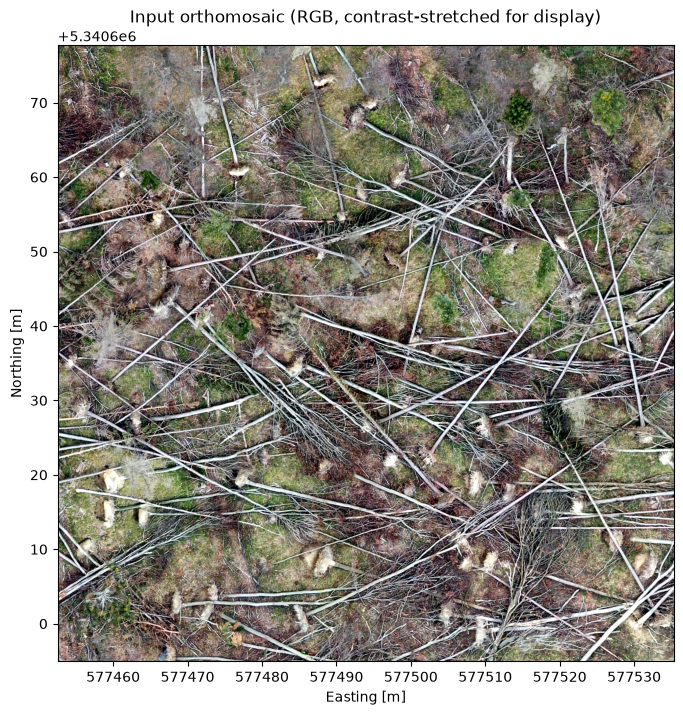

In [5]:
with rasterio.open(ORTHO_PATH) as src:
    w = min(WINDOW_SIZE, src.width)
    h = min(WINDOW_SIZE, src.height)
    col = (src.width - w) // 2 if COL_OFF is None else COL_OFF
    row = (src.height - h) // 2 if ROW_OFF is None else ROW_OFF
    window = Window(col, row, w, h)
    bands = min(3, src.count)
    data = src.read(list(range(1, bands + 1)), window=window)
    profile0 = src.profile.copy()
    profile0.update(width=w, height=h, count=bands,
                    transform=src.window_transform(window), driver="GTiff")
    profile0.pop("nodata", None)

file_name = "notebook_crop"
crop_path = os.path.join(pred_dir, file_name + "_input.tif")
with rasterio.open(crop_path, "w", **profile0) as dst:
    dst.write(data)

img, profile = Analyzer.IO.load_orthomosaic(crop_path, config)
EXTENT = extent_from_profile(profile)
img_disp = stretch_rgb(img)   # display-only; `img` (raw) still feeds the model
print("Window:", img.shape, "| CRS", profile.get("crs"))

plt.figure(figsize=(8, 8))
plt.imshow(img_disp, extent=EXTENT)
plt.title("Input orthomosaic (RGB, contrast-stretched for display)")
plt.xlabel("Easting [m]"); plt.ylabel("Northing [m]")
plt.show()

## 4. Predict the semantic stem map

The U-Net runs tile-by-tile (resampled to the model's 512 px input). Output is a
binary stem / non-stem raster.

#######################################################
Prediction of the semantic stem map
Resampling tiles while analyzing


2026-07-09 13:35:17.264469: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


36  tiles analyzed
Elapsed time: 11.0578 seconds
#######################################################

Elapsed time: 11.0617 seconds


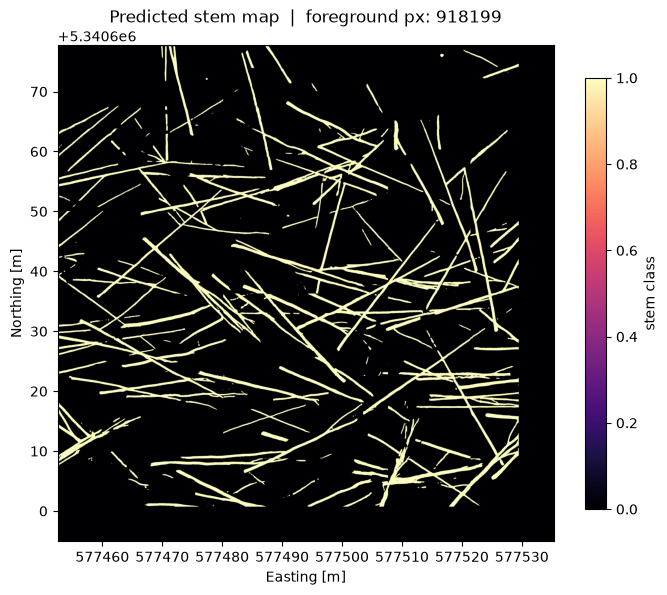

In [6]:
tt = Timer(); tt.start()
pred, profile = Analyzer.Pred.predict_with_resampling_per_tile(
    img, profile, model, config)
tt.stop()

plt.figure(figsize=(8, 8))
plt.imshow(pred, cmap="magma", extent=EXTENT)
plt.title("Predicted stem map  |  foreground px: %d" % int((pred >= 1).sum()))
plt.xlabel("Easting [m]"); plt.ylabel("Northing [m]")
plt.colorbar(shrink=0.7, label="stem class")
plt.show()

## 5. Skeletonize & detect segments

The stem map is thinned to a 1-px skeleton, split at branch/end points into
segments. (Stage stats are printed by the function.)

In [7]:
segments = Analyzer.Skel.find_segments(pred, config, profile)
print("Raw skeleton segments:", len(segments))

#######################################################
Skeletonize Image


Elapsed time: 0.4625 seconds
#######################################################

#######################################################
Splitting the skeleton into segments and detecting endnodes


Dense nodes removed:  54
Elapsed time: 1.0881 seconds
Find skeletion nodes


Remove branch points
Find skeletion nodes


Branch points removed:  1677
Detected end nodes:  2666
Elapsed time: 0.9610 seconds
#######################################################

#######################################################
Find connected segments in the skeleton
Initial length of skeleton:  64739
Number of end nodes 2666
Minimum length in pixel:  4


Detected skeleton segments:  934
Elapsed time: 0.9461 seconds
#######################################################

#######################################################
#Refining and sorting out skeleton segments
Initial length of skeleton:  63414
Number of initial skeleton segments 934


Number of split segments: 434
Number of removed segments: 606
Number of refined segments: 762
Elapsed time: 1.4666 seconds
#######################################################

Raw skeleton segments: 762


## 6. Restore geoinformation & build stem parts

#######################################################
Restoring geoinformation
Elapsed time: 0.0082 seconds
#######################################################

#######################################################
Build stem segments
762 stems segments build
Elapsed time: 0.0097 seconds
#######################################################

Stem segments before connection: 762


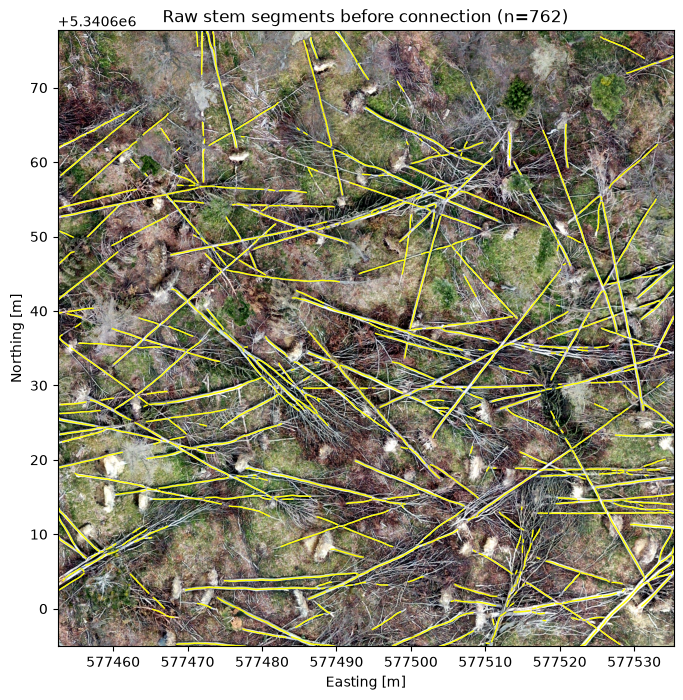

In [8]:
segments = Analyzer.Vec.restore_geoinformation(segments, config, profile)
stems_raw = Analyzer.Vec.build_stem_parts(segments)
print("Stem segments before connection:", len(stems_raw))

gdf_raw = Analyzer.IO.stems_to_gdf(stems_raw, profile)
plt.figure(figsize=(8, 8))
plt.imshow(img_disp, extent=EXTENT)
gdf_raw.plot(ax=plt.gca(), color="yellow", linewidth=1.0)
plt.title("Raw stem segments before connection (n=%d)" % len(stems_raw))
plt.xlabel("Easting [m]"); plt.ylabel("Northing [m]")
plt.show()

## 7. Connect stems

Fragmented and occluded segments are heuristically joined into whole stems.

#######################################################
Gathering stem segments
Cycle  1


Cycle  2


Cycle  3



762 stem segments analyzed
203 stem segments appended to other stems
113 duplicates are removed
244 stem fragments with a length less than  2.0 m are filtered out
final number of stems 202
Elapsed time: 3.1176 seconds
#######################################################

#######################################################
Rebuild endnodes from stems
Elapsed time: 0.0020 seconds
#######################################################

Stems after connection: 202


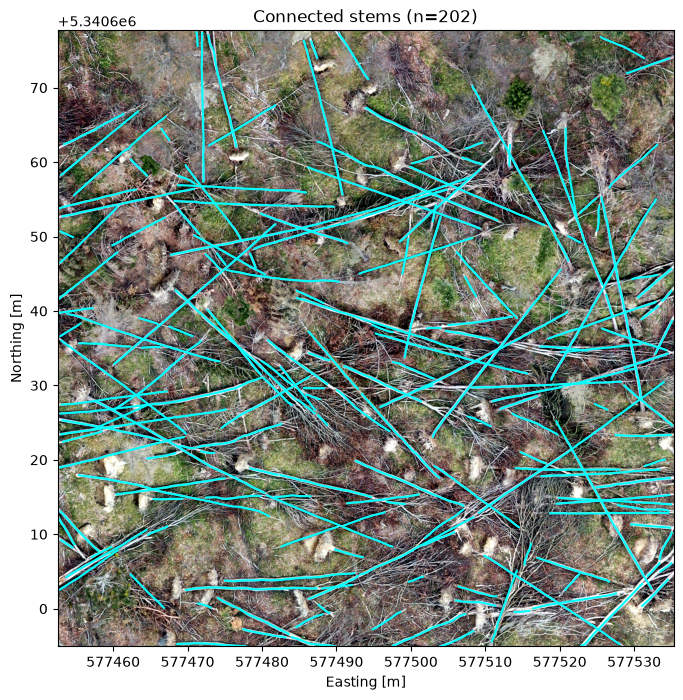

In [9]:
stems = Analyzer.Vec.connect_stems(stems_raw, config)
Analyzer.Vec.rebuild_endnodes_from_stems(stems)
print("Stems after connection:", len(stems))

gdf_conn = Analyzer.IO.stems_to_gdf(stems, profile)
plt.figure(figsize=(8, 8))
plt.imshow(img_disp, extent=EXTENT)
gdf_conn.plot(ax=plt.gca(), color="cyan", linewidth=1.5)
plt.title("Connected stems (n=%d)" % len(stems))
plt.xlabel("Easting [m]"); plt.ylabel("Northing [m]")
plt.show()

## 8. Quantify stems

Diameters are sampled every `measuring_point_spacing_m` along each stem and
volume is integrated as a chain of truncated cones.

In [10]:
stems = Analyzer.Quant.quantify_stems(stems, pred, profile)
gdf = Analyzer.IO.stems_to_gdf(stems, profile)
print("%d stems | total length %.1f m | total volume %.2f m3"
      % (len(stems), gdf["length"].sum(), gdf["volume"].sum()))
gdf[["length", "volume"]].describe()

#######################################################
Quantifying stems


3084  measurements of diameters where conducted


Volume of  202  stems calculated
Elapsed time: 6.4805 seconds
#######################################################

202 stems | total length 1969.0 m | total volume 244.66 m3


,length,volume
count,202.000000,202.000000
mean,9.747768,1.211180
std,7.520730,1.167602
min,2.032370,0.037192
25%,3.342945,0.347391
50%,7.527001,0.823238
75%,13.756281,1.681512
max,30.694238,5.343265


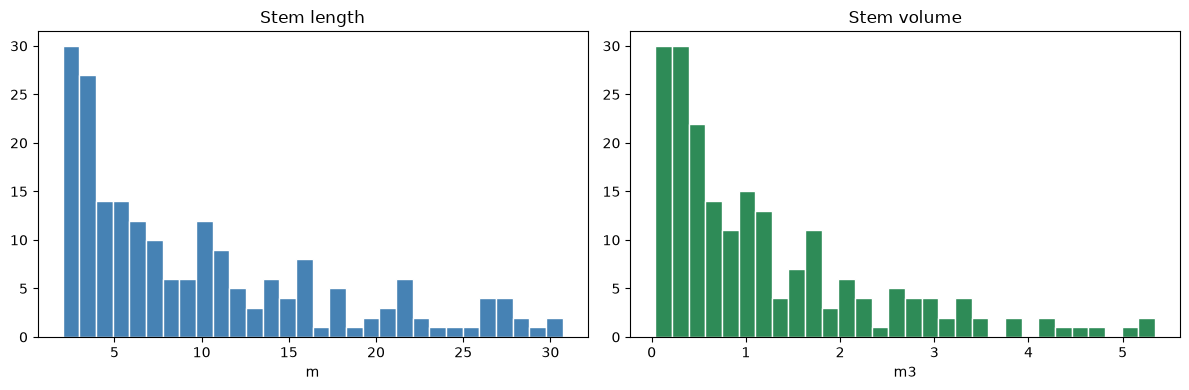

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(gdf["length"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Stem length"); axes[0].set_xlabel("m")
axes[1].hist(gdf["volume"], bins=30, color="seagreen", edgecolor="white")
axes[1].set_title("Stem volume"); axes[1].set_xlabel("m3")
plt.tight_layout(); plt.show()

## 9. Final result — stems colored by volume

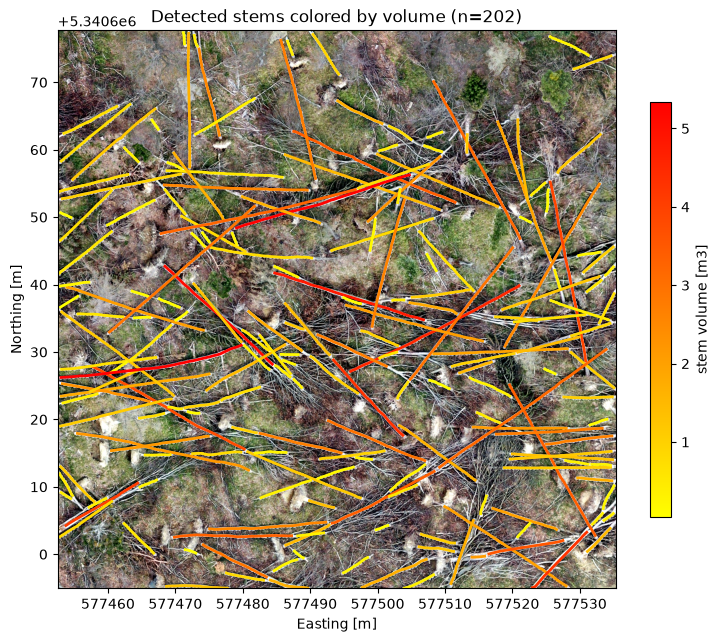

In [12]:
gdf_nodes = Analyzer.IO.nodes_to_gdf(stems, profile)
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(img_disp, extent=EXTENT)
gdf.plot(ax=ax, column="volume", cmap="autumn_r", linewidth=2.0, legend=True,
         legend_kwds={"label": "stem volume [m3]", "shrink": 0.6})
gdf_nodes.plot(ax=ax, color="white", markersize=2, alpha=0.5)
ax.set_title("Detected stems colored by volume (n=%d)" % len(stems))
ax.set_xlabel("Easting [m]"); ax.set_ylabel("Northing [m]")
plt.show()

## 10. Export outputs

In [13]:
Analyzer.IO.export_stem_map(pred, profile, pred_dir, file_name)
gpkg_path = Analyzer.IO.write_all_layers_to_gpkg(
    stems, profile, os.path.join(output_dir, file_name))
print("Stem map  ->", os.path.join(pred_dir, file_name + ".tiff"))
print("GeoPackage->", gpkg_path)

Geopackage written to temporary file: /Users/christian/hnee/WINMOL_Analyzer/standalone/output/winmol_gpkg_d4eaytsv/notebook_crop.gpkg
Stem map  -> /Users/christian/hnee/WINMOL_Analyzer/standalone/pred/notebook_crop.tiff
GeoPackage-> /Users/christian/hnee/WINMOL_Analyzer/standalone/output/notebook_crop.gpkg
